In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import os

In [ ]:
# settings
work_directory = r'C:\Users\...\Code'
os.chdir(work_directory)

# setting: font
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)  # pass in the font dict as kwargs

### Data preprocess

In [ ]:
# loading data

data_directory = '.../basins_5245.csv'
original_data = pd.read_table(data_directory, sep=',', header=0, index_col='OBSID1')
columns_of_interest = ['EBE_MMKYR', 'EBE_ERR', 'GLA_PCNT', 'MATERIAL', 'AREA', 'SLP_deg', 'ELEV_AVE', 'QTZ_PCNT',
                       'SLP_AVE','rock_major', 'rock_count', 'MAP', 'MAT', 'AI', 'NDVI_STS']

data0 = original_data[columns_of_interest].copy()
data0["NDVI"] = data0["NDVI_STS"]

# exclude nodata
Nodata = data0[['MAP', 'NDVI']].isin([-9999]).any(axis=1)
data0 = data0[~Nodata]

# restrict sample materials to "sand" only
data0 = data0[data0['MATERIAL'].isin(['Sa', 'Sed'])]

# depending on the resolution of raster data is about 1 km
data0 = data0[data0['AREA'] > 10]
data0 = data0[data0['AREA'] < 1000]

# denudation, precipitation, and area
data0 = data0[data0['EBE_MMKYR'] >= data0['EBE_MMKYR'].quantile(0.05)]
data0 = data0[data0['EBE_MMKYR'] <= data0['EBE_MMKYR'].quantile(0.95)]

# MAP
data0 = data0[data0['MAP'] <= data0['MAP'].quantile(0.90)]

data0
# data0['NDVI'].describe()
# data0['MAP'].describe()

,EBE_MMKYR,EBE_ERR,GLA_PCNT,MATERIAL,AREA,SLP_deg,ELEV_AVE,QTZ_PCNT,SLP_AVE,rock_major,rock_count,MAP,MAT,AI,NDVI_STS,NDVI
OBSID1,,,,,,,,,,,,,,,,
S141WTS002,23.53,4.24,9.62,Sa,270.30,15.435900,5513.65,1.0,276.12,mt,51.0,176.154999,-8.439930,1909.099976,0.096232,0.096232
S075WTS009,244.15,47.62,0.01,Sa,238.04,22.651800,1348.00,100.0,417.32,mt,72.0,1644.180054,3.924200,17418.500000,0.737846,0.737846
S304WTS005,903.41,170.07,8.13,Sa,257.45,28.607599,2457.29,30.0,545.39,mt,74.0,1142.030029,0.114006,13731.299805,0.407215,0.407215
S293WTS010,818.55,149.97,13.90,Sa,284.95,26.072001,4791.19,78.0,489.29,pa,78.0,668.109985,-2.454970,8520.120117,0.201538,0.201538
S101WTS021,33.97,6.16,7.83,Sa,208.89,24.919600,4721.40,100.0,464.60,pa,85.0,110.887001,-4.870720,1140.030029,0.109365,0.109365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S281WTS029,8.27,1.99,0.00,Sa,10.86,6.461780,313.59,100.0,113.26,sm,100.0,808.786011,18.387800,4630.500000,0.702000,0.702000
S299WTS004,14.77,3.33,0.00,Sa,34.13,11.056300,371.56,100.0,195.40,pa,100.0,1147.819946,10.992100,10569.799805,0.845244,0.845244
S162WTS004,9.94,2.55,0.00,Sa,28.26,1.118840,281.20,100.0,19.53,pa,97.0,665.843994,23.463900,3067.489990,0.467172,0.467172


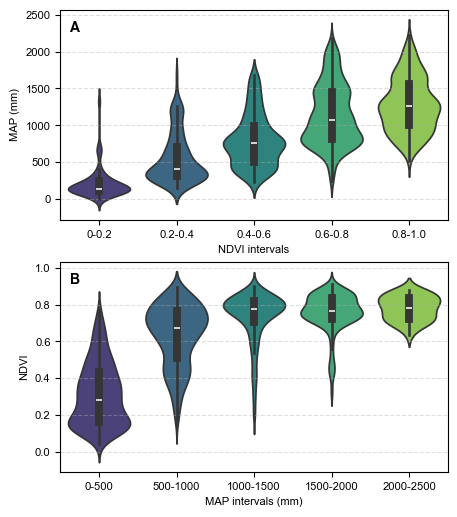

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
#  NDVI → MAP (A)
# ======================
ndvi_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
ndvi_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
data0["NDVI_group"] = pd.cut(data0["NDVI"], bins=ndvi_bins,
                             labels=ndvi_labels, include_lowest=True)

# ======================
#  MAP → NDVI (B)
# ======================
MAP_bins = np.arange(0, 2500 + 1, 500)
MAP_labels = [f"{MAP_bins[i]}-{MAP_bins[i+1]}" for i in range(len(MAP_bins)-1)]
data0["MAP_group"] = pd.cut(data0["MAP"], bins=MAP_bins,
                            labels=MAP_labels, include_lowest=True)

# ======================
#  plot
# ======================
fig, axes = plt.subplots(2, 1, figsize=(5, 6), dpi=100)

# ---- A ----
sns.violinplot(
    data=data0,
    x="NDVI_group",
    y="MAP",
    hue="NDVI_group",
    legend=False,
    dodge=False,
    inner="box",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_xlabel("NDVI intervals")
axes[0].set_ylabel("MAP (mm)")
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# A 
axes[0].text(0.05, 0.95, 'A', transform=axes[0].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')

# ---- B ----
sns.violinplot(
    data=data0,
    x="MAP_group",
    y="NDVI",
    hue="MAP_group",
    legend=False,
    dodge=False,
    inner="box",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_xlabel("MAP intervals (mm)")
axes[1].set_ylabel("NDVI")
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# B 
axes[1].text(0.05, 0.95, 'B', transform=axes[1].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')
# plt.tight_layout()
# plt.show()
# plt.savefig("Results/260309/Figure 5.svg", dpi=100, bbox_inches='tight')